<a href="https://colab.research.google.com/github/Pameta1/Telecom_X/blob/main/TelecomX_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##📌 Extracción de datos

In [1]:
import pandas as pd

In [2]:
datos = pd.read_json('/content/TelecomX_Data.json')

In [3]:
import warnings
warnings.filterwarnings('ignore')

#### Conociendo los datos

In [4]:
datos_cliente = pd.DataFrame(datos)

In [5]:
# Ver las primeras filas
datos_cliente.head(2)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [6]:
# Ver número de filas y columnas
datos_cliente.shape

(7267, 6)

In [7]:
# Información general del DataFrame
datos_cliente.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [8]:
# Estadísticas descriptivas de variables numéricas
datos_cliente.describe()

,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [9]:
# Listar todas las columnas
datos_cliente.columns.tolist()

['customerID', 'Churn', 'customer', 'phone', 'internet', 'account']

 #### Identificar las columnas más relevantes para el análisis de evasión



#### Columnas más relevantes para el análisis

Las columnas clave serían:

| Columna    | Relevancia          | Motivo                                                  |
| ---------- | ------------------- | ------------------------------------------------------- |
| customerID | ❌ No relevante      | Identificador único, no aporta información predictiva   |
| Churn      | ✅ Variable objetivo | Indica si el cliente canceló                            |
| customer   | ⚠️ Parcial          | Información demográfica del cliente                     |
| phone      | ✅ Relevante         | Servicios telefónicos influyen en churn                 |
| internet   | ✅ Muy relevante     | Tipo de servicio de internet suele ser predictor fuerte |
| account    | ✅ Relevante         | Información de facturación y pagos afecta cancelación   |


In [10]:
# Lista de columnas relevantes
relevant_columns = ['Churn', 'customer', 'phone', 'internet', 'account']

In [11]:
# crear dataframe con columnas relevantes
df_relevant = datos_cliente[relevant_columns]

# visualizar
df_relevant.head(2)


,Churn,customer,phone,internet,account
0,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


####Comprobación de incoherencias en los datos

In [12]:
# Convertir todas las columnas a string para poder revisar duplicados y valores únicos
df_relevant_str = df_relevant.astype(str)

In [13]:
#  1. Verificar valores ausentes
df_relevant.isnull().sum()

,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [14]:
#  Verificar duplicados
print("Duplicados:", df_relevant_str.duplicated().sum())

Duplicados: 22


In [15]:
#  Revisar tipos de datos
print("\nTipos de datos por columna:")
print(df_relevant.dtypes)


Tipos de datos por columna:
Churn       object
customer    object
phone       object
internet    object
account     object
dtype: object


In [16]:
#  Contar frecuencia de categorías
for col in df_relevant.columns:
    df_relevant[col].value_counts()

#### Manejo de inconsistencias

In [17]:
#  Detectar columnas que contienen diccionarios/listas y expandirlas
for col in df_relevant.columns:
    # Revisar si la columna contiene diccionarios o listas
    if df_relevant[col].apply(lambda x: isinstance(x, (dict, list))).any():
        print(f"Expandiendo columna: {col}")

        # Normalizar la columna (convierte dict/list en columnas planas)
        expandido = pd.json_normalize(df_relevant[col])

        # Renombrar columnas para evitar conflictos
        expandido = expandido.add_prefix(f"{col}_")

        # Eliminar la columna original y unir la expandida
        df_relevant = df_relevant.drop(columns=[col]).join(expandido)

#  Verificar el resultado
print("\nColumnas después de la expansión:")
print(df_relevant.columns.tolist())

print("\nPrimeras filas del DataFrame limpio:")
print(df_relevant.head())

Expandiendo columna: customer
Expandiendo columna: phone
Expandiendo columna: internet
Expandiendo columna: account

Columnas después de la expansión:
['Churn', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges.Monthly', 'account_Charges.Total']

Primeras filas del DataFrame limpio:
  Churn customer_gender  customer_SeniorCitizen customer_Partner  \
0    No          Female                       0              Yes   
1    No            Male                       0               No   
2   Yes            Male                       0               No   
3   Yes            Male                       1              Yes   

 Qué hace este código

- Recorre todas las columnas de DataFrame.
- Detecta si contienen diccionarios o listas.
- Expande esas columnas con pd.json_normalize() para convertirlas en columnas planas.
- Renombra las nuevas columnas con un prefijo (customer_, phone_, etc.) para mantener claridad.
- Reemplaza la columna original por las expandidas.


Eliminar espacios en blanco

In [18]:
for col in df_relevant.columns:
    df_relevant[col] = df_relevant[col].astype(str).str.strip()

Eliminar valores nulos

In [19]:
df_relevant = df_relevant.dropna()

Eliminar duplicados

In [20]:
df_relevant= df_relevant.drop_duplicates()
print("Duplicados eliminados. Filas actuales:", df_relevant.shape[0])

Duplicados eliminados. Filas actuales: 7245


In [21]:
print("Valores nulos después de limpieza:")
(df_relevant.isnull().sum())


Valores nulos después de limpieza:


,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0
internet_OnlineSecurity,0


In [56]:
for col in ['customer', 'phone', 'internet', 'account']:
    if col in df_relevant.columns:
        print(f"\nValores únicos en {col}:")
        print(df_relevant[col].unique())


In [57]:
# Normalizar strings en columnas categóricas
for col in df_relevant.select_dtypes(include='object').columns:
    df_relevant[col] = df_relevant[col].str.strip().str.lower()

In [58]:
print("Columnas actuales en el DataFrame:")
print(df_relevant.columns.tolist())

Columnas actuales en el DataFrame:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias', 'Gasto_Diario_Historico']


####Creación de columna Cuentas Diarias

In [59]:
df_relevant['Charges.Monthly'] = pd.to_numeric(df_relevant['Charges.Monthly'], errors='coerce')

#  Crear columna de cuentas diarias a partir de MonthlyCharges
df_relevant['Cuentas_Diarias'] = df_relevant['Charges.Monthly'] / 30


# Verificar la nueva columna
print(df_relevant[['Charges.Monthly', 'Cuentas_Diarias']].head())

   Charges.Monthly  Cuentas_Diarias
0             65.6         2.186667
1             59.9         1.996667
2             73.9         2.463333
3             98.0         3.266667
4             83.9         2.796667


**Explicación**

- pd.to_numeric(..., errors='coerce') convierte la columna a números y reemplaza cualquier valor inválido por NaN.
- Una vez convertida, ya puedes dividir entre 30 sin que aparezca el error de tipo.
- La nueva columna Cuentas_Diarias queda lista para análisis descriptivo y comparativo.



In [60]:
df_relevant['Charges.Total'] = pd.to_numeric(df_relevant['Charges.Total'], errors='coerce')
df_relevant['tenure'] = pd.to_numeric(df_relevant['tenure'], errors='coerce')

df_relevant['Gasto_Diario_Historico'] = df_relevant['Charges.Total'] / (df_relevant['tenure'] * 30)

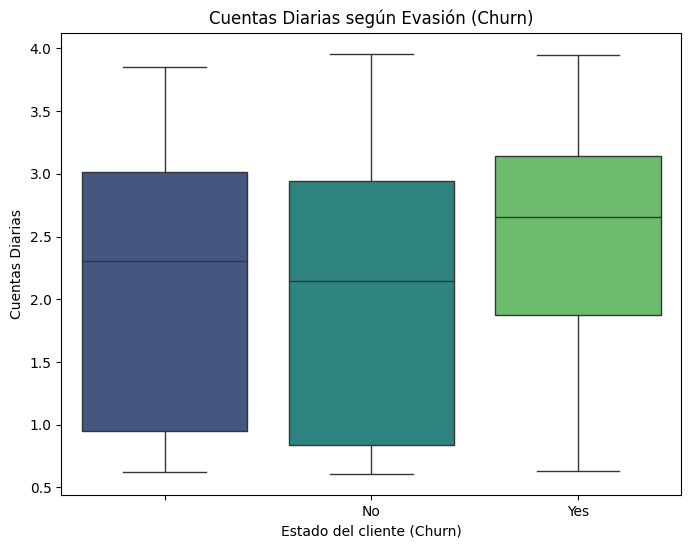

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usar la columna correcta para churn
col_objetivo = 'Churn' if 'Churn' in df_relevant.columns else 'cancelacion'

plt.figure(figsize=(8,6))
sns.boxplot(data=df_relevant, x=col_objetivo, y='Cuentas_Diarias', palette="viridis")
plt.title("Cuentas Diarias según Evasión (Churn)")
plt.xlabel("Estado del cliente (Churn)")
plt.ylabel("Cuentas Diarias")
plt.show()

 Interpretación
- Si el boxplot de clientes que cancelaron muestra valores más altos o más dispersos en Cuentas_Diarias, puede indicar que el gasto diario influye en la decisión de cancelar.
- Si ambos grupos son similares, entonces el gasto diario no parece ser un factor determinante.
- Los outliers (puntos fuera de la caja) pueden señalar clientes con comportamientos extremos que vale la pena analizar aparte.


##🔧 Transformación de los datos

In [107]:
#  Copia del DataFrame para trabajar
df_clean = df_relevant.copy()

#  Convertir valores textuales "Sí"/"No" en binarios (1/0)
# Supongamos que la columna 'Churn' tiene valores "Sí" y "No"
df_clean['Churn_bin'] = df_clean['Churn'].map({'Sí': 1, 'No': 0})

#### Renombrar columnas

In [108]:
# Renombrar columnas a nombres más claros en español
df_clean = df_relevant.rename(columns={
    'customerID': 'cliente',
    'PhoneService': 'telefono',
    'InternetService': 'internet',
    'Charges.Monthly': 'cargo mensual',
    'Churn': 'cancelacion',
    'Charges.Total': 'cargo total'
})

print("Columnas renombradas:")
print(df_clean.columns.tolist())

Columnas renombradas:
['cliente', 'cancelacion', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'telefono', 'MultipleLines', 'internet', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'cargo mensual', 'cargo total', 'Cuentas_Diarias', 'Gasto_Diario_Historico']


In [109]:
#  Codificación One-Hot para variables categóricas
# Ejemplo: transformar 'internet' en columnas binarias
df_clean = pd.get_dummies(df_clean, columns=['internet', 'telefono', 'cancelacion'], drop_first=True)

# Estandarización de variables numéricas (opcional)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_clean[['Cuentas_Diarias']] = scaler.fit_transform(df_clean[['Cuentas_Diarias']])

#  Verificación final
print("Columnas después de transformación:")
print(df_clean.columns.tolist())

print("\nPrimeras filas del DataFrame transformado:")
print(df_clean.head())


Columnas después de transformación:
['cliente', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'cargo mensual', 'cargo total', 'Cuentas_Diarias', 'Gasto_Diario_Historico', 'internet_Fiber optic', 'internet_No', 'telefono_Yes', 'cancelacion_No', 'cancelacion_Yes']

Primeras filas del DataFrame transformado:
      cliente  gender  SeniorCitizen Partner Dependents  tenure MultipleLines  \
0  0002-ORFBO  Female              0     Yes        Yes       9            No   
1  0003-MKNFE    Male              0      No         No       9           Yes   
2  0004-TLHLJ    Male              0      No         No       4            No   
3  0011-IGKFF    Male              1     Yes         No      13            No   
4  0013-EXCHZ  Female              1     Yes         No       3            No   

  OnlineSecurity Onli

#### Homogeneizar categorias

In [110]:
# Normalizar texto en columnas categóricas
for col in ['cliente', 'telefono_Yes', 'internet_Fiber optic', 'cargo mensual']:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.lower()

# Ejemplo: traducir métodos de pago
df_clean['cargo mensual'] = df_clean['cargo mensual'].replace({
    'electronic check': 'cheque electrónico',
    'credit card': 'tarjeta de crédito',
    'bank transfer': 'transferencia bancaria',
    'mailed check': 'cheque enviado'
})

In [111]:
#  Verificación final
print("Columnas después de transformación:")
(df_clean.columns.tolist())

print("\nPrimeras filas del DataFrame transformado:")
(df_clean.head(2))

Columnas después de transformación:

Primeras filas del DataFrame transformado:


,cliente,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaymentMethod,cargo mensual,cargo total,Cuentas_Diarias,Gasto_Diario_Historico,internet_Fiber optic,internet_No,telefono_Yes,cancelacion_No,cancelacion_Yes
0,0002-orfbo,Female,0,Yes,Yes,9,No,No,Yes,No,...,Mailed check,65.6,593.3,0.029206,2.197407,false,False,true,True,False
1,0003-mknfe,Male,0,No,No,9,Yes,No,No,No,...,Mailed check,59.9,542.4,-0.159990,2.008889,false,False,true,True,False


####Análisis descriptivo

In [112]:
#  Estadísticas descriptivas generales
df_clean.describe(include='all')

,cliente,gender,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaymentMethod,cargo mensual,cargo total,Cuentas_Diarias,Gasto_Diario_Historico,internet_Fiber optic,internet_No,telefono_Yes,cancelacion_No,cancelacion_Yes
count,7267,7267,7267.000000,7267,7267,7267.000000,7267,7267,7267,7267,...,7267,7267,7256.000000,7.267000e+03,7256.000000,7267,7267,7267,7267,7267
unique,7267,2,NaN,2,2,NaN,3,3,3,3,...,4,1585,NaN,NaN,NaN,2,2,2,2,2
top,9995-hotoh,Male,NaN,No,No,NaN,No,No,No,No,...,Electronic check,20.05,NaN,NaN,NaN,false,False,true,True,False
freq,1,3675,NaN,3749,5086,NaN,3495,3608,3182,3195,...,2445,65,NaN,NaN,NaN,4069,5686,6560,5174,5398
mean,NaN,NaN,0.162653,NaN,NaN,32.346498,NaN,NaN,NaN,NaN,...,NaN,NaN,2280.634213,2.214641e-16,2.158564,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.369074,NaN,NaN,24.571773,NaN,NaN,NaN,NaN,...,NaN,NaN,2268.632997,1.000069e+00,1.007442,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,18.800000,-1.542448e+00,0.459167,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,400.225000,-9.723707e-01,1.191667,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,1391.000000,1.852096e-01,2.341667,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,3785.300000,8.349482e-01,3.005985,NaN,NaN,NaN,NaN,NaN


In [113]:
#  Métricas específicas de Cuentas_Diarias
print("\nMétricas de Cuentas_Diarias:")
print("Media:", df_clean['Cuentas_Diarias'].mean())
print("Mediana:", df_clean['Cuentas_Diarias'].median())
print("Desviación estándar:", df_clean['Cuentas_Diarias'].std())
print("Mínimo:", df_clean['Cuentas_Diarias'].min())
print("Máximo:", df_clean['Cuentas_Diarias'].max())


Métricas de Cuentas_Diarias:
Media: 2.214640562125536e-16
Mediana: 0.18520960999656222
Desviación estándar: 1.0000688112851295
Mínimo: -1.542447916134888
Máximo: 1.793374972937365


In [114]:
# Seleccionar la variable objetivo
y = df_clean['cancelacion_Yes']

# Eliminar la columna redundante
df_clean = df_clean.drop(columns=['cancelacion_No'])

In [115]:
#  Distribución de la variable objetivo
print("\nDistribución de Cancelación:")
print(df_clean['cancelacion_Yes'].value_counts(normalize=True))


Distribución de Cancelación:
cancelacion_Yes
False    0.74281
True     0.25719
Name: proportion, dtype: float64


#### Distribución de evasión

In [116]:
#  Asegurar que la columna exista y esté limpia
col_objetivo = 'Churn' if 'Churn' in df_clean.columns else 'cancelacion_Yes'

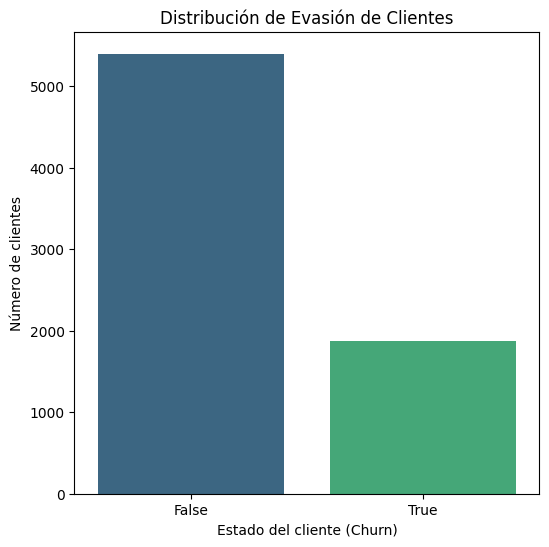


Distribución porcentual de evasión:
cancelacion_Yes
False    74.280996
True     25.719004
Name: proportion, dtype: float64


In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
# Distribución absoluta
conteo = df_clean[col_objetivo].value_counts()

plt.figure(figsize=(6,6))
sns.barplot(x=conteo.index, y=conteo.values, palette="viridis")
plt.title("Distribución de Evasión de Clientes")
plt.xlabel("Estado del cliente (Churn)")
plt.ylabel("Número de clientes")
plt.show()

# Distribución porcentual
porcentaje = df_clean[col_objetivo].value_counts(normalize=True) * 100
print("\nDistribución porcentual de evasión:")
print(porcentaje)

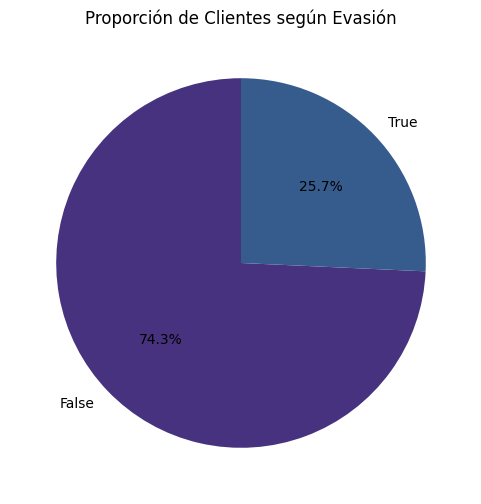

In [118]:
plt.figure(figsize=(6,6))
plt.pie(conteo.values, labels=conteo.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("viridis"))
plt.title("Proporción de Clientes según Evasión")
plt.show()

- El gráfico de barras te muestra el número absoluto de clientes que cancelaron vs. los que permanecieron.
- El gráfico circular te da una visión porcentual, ideal para presentaciones a stakeholders.
- El conteo y porcentaje te permiten cuantificar la magnitud del churn en tu dataset.


####Recuento de evasión por variables categóricas

In [119]:
# Verificar columnas actuales
print("Columnas disponibles en el DataFrame:")
print(df_clean.columns.tolist())

# Identificar columnas categóricas
categoricas = df_clean.select_dtypes(include='object').columns.tolist()
print("\nColumnas categóricas detectadas:")
print(categoricas)

Columnas disponibles en el DataFrame:
['cliente', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'cargo mensual', 'cargo total', 'Cuentas_Diarias', 'Gasto_Diario_Historico', 'internet_Fiber optic', 'internet_No', 'telefono_Yes', 'cancelacion_Yes']

Columnas categóricas detectadas:
['cliente', 'cargo mensual', 'internet_Fiber optic', 'telefono_Yes']



Distribución de evasión por tipo de contrato (%):
cancelacion_Yes      False      True 
Contract                             
Month-to-month   58.676654  41.323346
One year         89.071758  10.928242
Two year         97.246127   2.753873

Distribución de evasión por servicio de internet (%):
cancelacion_Yes           False      True 
internet_Fiber optic                      
false                 85.942492  14.057508
true                  59.443402  40.556598

Distribución de evasión por método de pago (%):
cancelacion_Yes                False      True 
PaymentMethod                                  
Bank transfer (automatic)  83.763373  16.236627
Credit card (automatic)    85.204082  14.795918
Electronic check           56.196319  43.803681
Mailed check               81.501502  18.498498


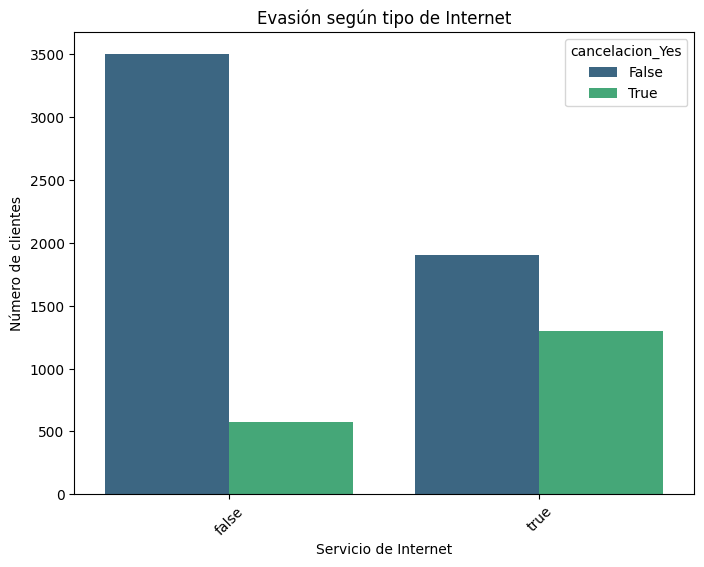

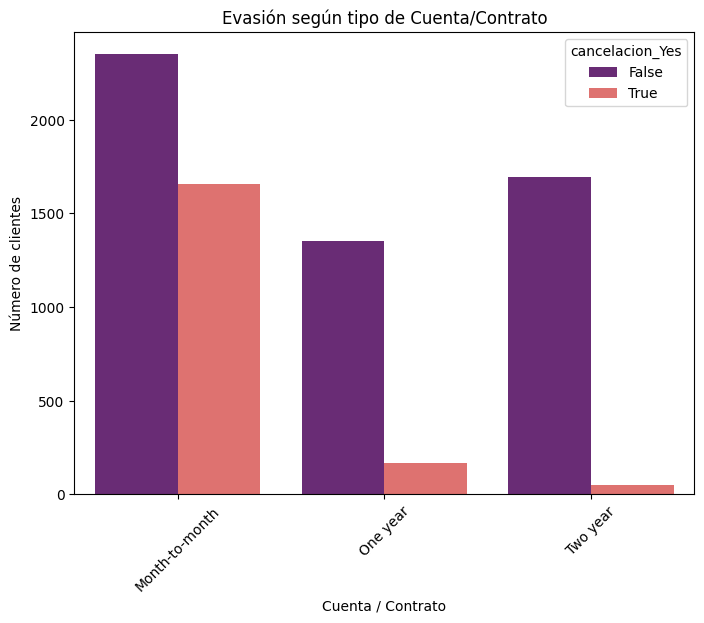

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ejemplo 1: distribución por tipo de contrato
tabla_contrato = pd.crosstab(df_clean['Contract'], df_clean[col_objetivo], normalize='index') * 100
print("\nDistribución de evasión por tipo de contrato (%):")
print(tabla_contrato)

#  Ejemplo 2: distribución por servicio de internet
tabla_internet = pd.crosstab(df_clean['internet_Fiber optic'], df_clean[col_objetivo], normalize='index') * 100
print("\nDistribución de evasión por servicio de internet (%):")
print(tabla_internet)

#  Ejemplo 3: distribución por método de pago
tabla_pago = pd.crosstab(df_clean['PaymentMethod'], df_clean[col_objetivo], normalize='index') * 100
print("\nDistribución de evasión por método de pago (%):")
print(tabla_pago)

#  Visualización con gráficos de barras
plt.figure(figsize=(8,6))
sns.countplot(data=df_clean, x='internet_Fiber optic', hue=col_objetivo, palette="viridis")
plt.title("Evasión según tipo de Internet")
plt.xlabel("Servicio de Internet")
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,6))
sns.countplot(data=df_clean, x='Contract', hue=col_objetivo, palette="magma")
plt.title("Evasión según tipo de Cuenta/Contrato")
plt.xlabel("Cuenta / Contrato")
plt.ylabel("Número de clientes")
plt.xticks(rotation=45)
plt.show()


- Tablas porcentuales: muestran qué porcentaje de clientes canceló dentro de cada categoría (ej. contrato mensual vs. anual).
- Gráficos de barras: permiten visualizar rápidamente si ciertos perfiles (ej. clientes con internet fibra óp


#📊 Carga y análisis

Boxplots comparativos por variables numéricas

In [50]:
# Verificar columnas actuales
print("Columnas disponibles en el DataFrame:")
print(df_clean.columns.tolist())

# Identificar columnas categóricas
categoricas = df_clean.select_dtypes(include='object').columns.tolist()
print("\nColumnas categóricas detectadas:")
print(categoricas)

Columnas disponibles en el DataFrame:
['cliente', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'cargo mensual', 'cargo total', 'Cuentas_Diarias', 'Gasto_Diario_Historico', 'internet_Fiber optic', 'internet_No', 'telefono_Yes', 'cancelacion_Yes']

Columnas categóricas detectadas:
['cliente', 'internet_Fiber optic', 'telefono_Yes', 'cancelacion_Yes']


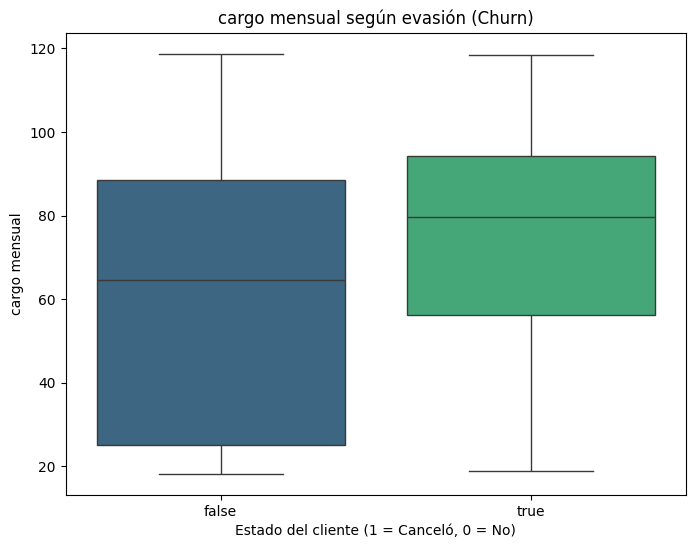

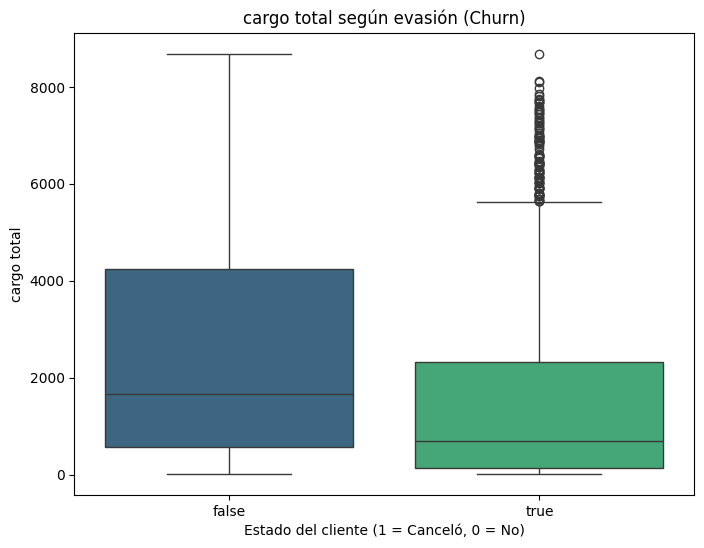

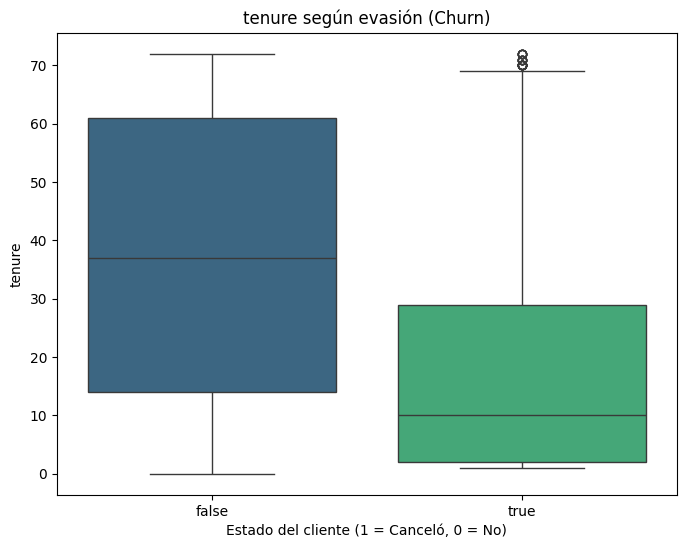

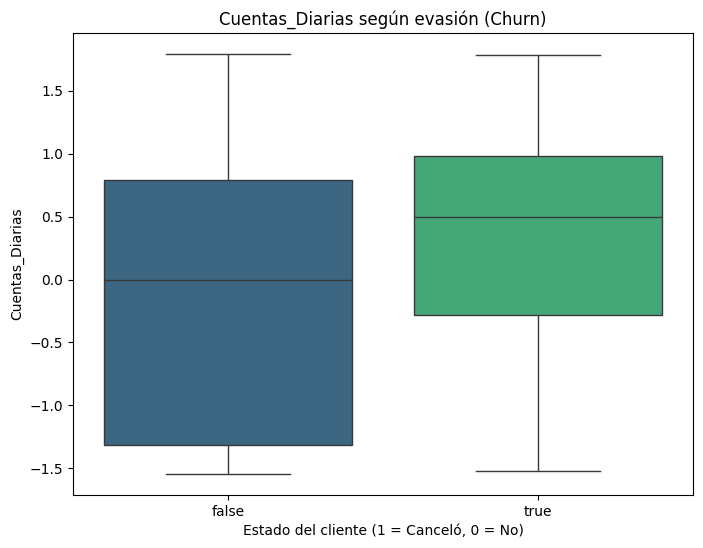

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

col_objetivo = 'cancelacion_Yes' if 'cancelacion_Yes' in df_clean.columns else 'Churn'

# Lista de variables numéricas relevantes
numericas = ['cargo mensual', 'cargo total', 'tenure', 'Cuentas_Diarias']

for col in numericas:
    if col in df_clean.columns:
        plt.figure(figsize=(8,6))
        sns.boxplot(data=df_clean, x=col_objetivo, y=col, palette="viridis")
        plt.title(f"{col} según evasión (Churn)")
        plt.xlabel("Estado del cliente (1 = Canceló, 0 = No)")
        plt.ylabel(col)
        plt.show()

Histograma comparativos:

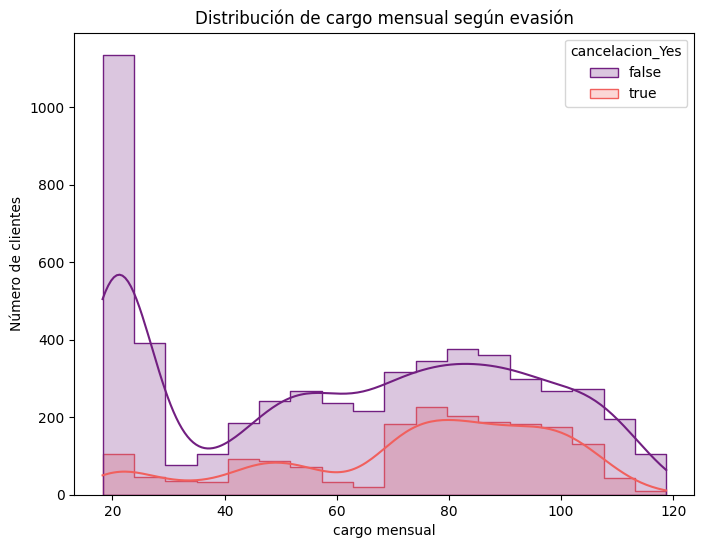

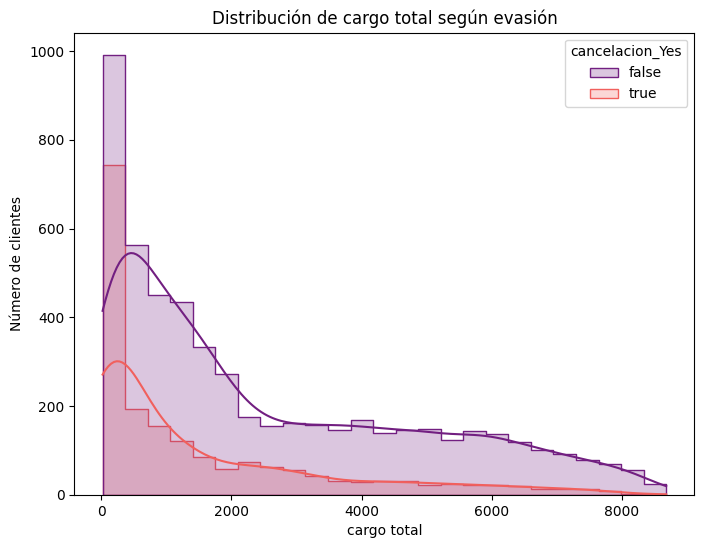

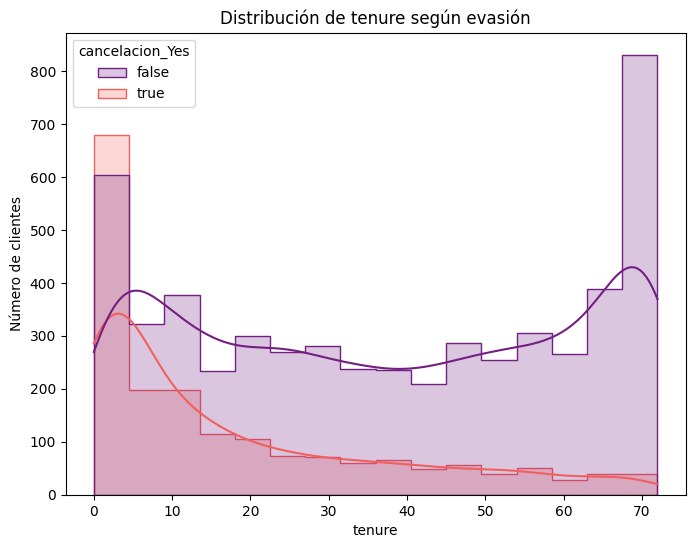

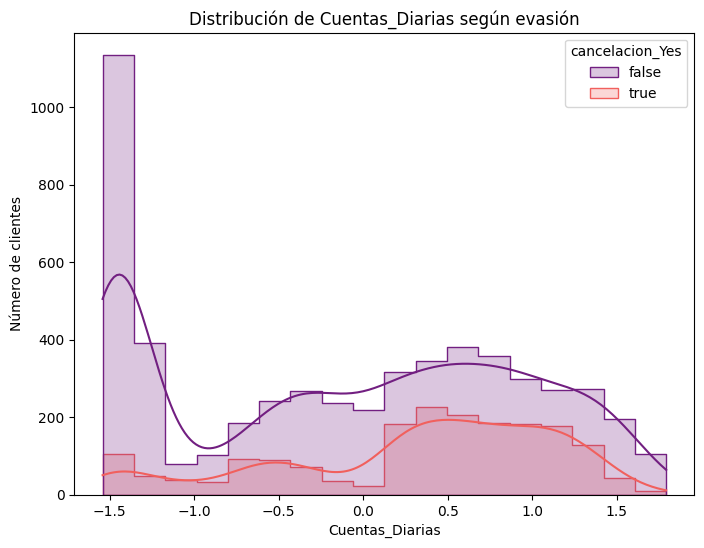

In [52]:
for col in numericas:
    if col in df_clean.columns:
        plt.figure(figsize=(8,6))
        sns.histplot(data=df_clean, x=col, hue=col_objetivo, kde=True, palette="magma", element="step")
        plt.title(f"Distribución de {col} según evasión")
        plt.xlabel(col)
        plt.ylabel("Número de clientes")
        plt.show()

Interpretación
- cargo mensual: si los clientes que cancelan tienen cargos mensuales más altos, puede indicar sensibilidad al precio.
- cargo total: valores bajos asociados a cancelación pueden reflejar clientes nuevos que se van rápido.
- tenure: si los que cancelan tienen menor tiempo de contrato, significa que la fidelización es débil en los primeros meses.
- Cuentas_Diarias: permite ver si el gasto diario promedio influye en la decisión de cancelar.


####Matriz de correlación

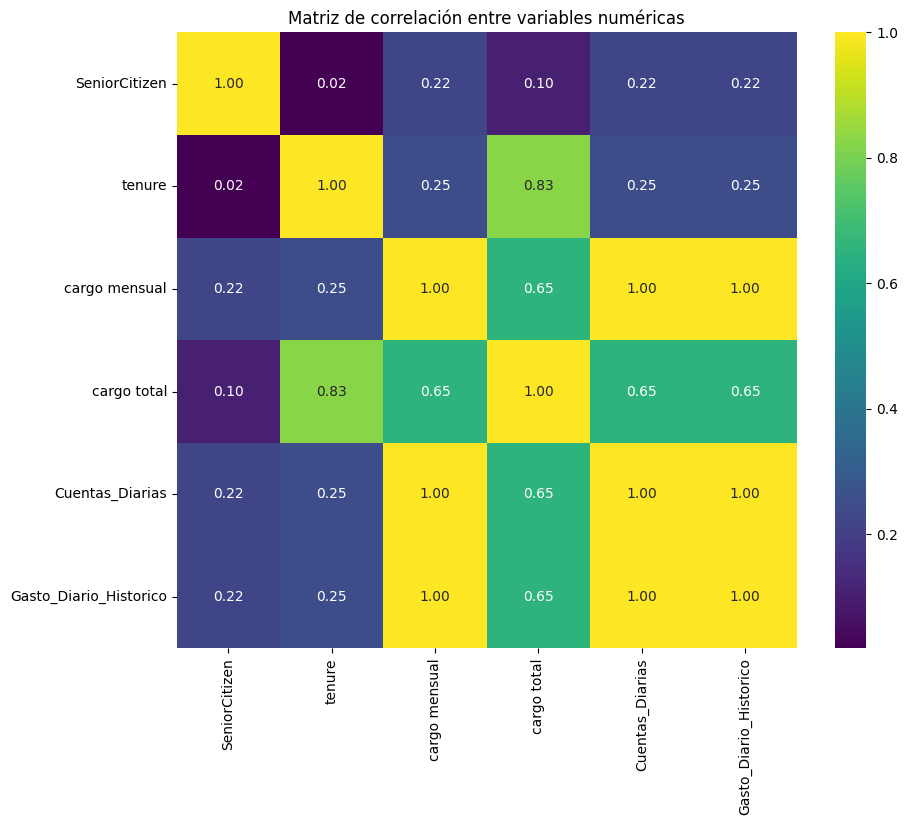

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar variables numéricas
numericas = df_clean.select_dtypes(include=['int64','float64']).columns.tolist()

# Calcular matriz de correlación
corr = df_clean[numericas].corr()

# Visualizar con heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

####Correlación específica con evación

In [54]:
# Verificar columnas actuales
print("Columnas disponibles en el DataFrame:")
print(df_clean.columns.tolist())

# Identificar columnas categóricas
categoricas = df_clean.select_dtypes(include='object').columns.tolist()
print("\nColumnas categóricas detectadas:")
print(categoricas)

Columnas disponibles en el DataFrame:
['cliente', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'cargo mensual', 'cargo total', 'Cuentas_Diarias', 'Gasto_Diario_Historico', 'internet_Fiber optic', 'internet_No', 'telefono_Yes', 'cancelacion_Yes']

Columnas categóricas detectadas:
['cliente', 'internet_Fiber optic', 'telefono_Yes', 'cancelacion_Yes']


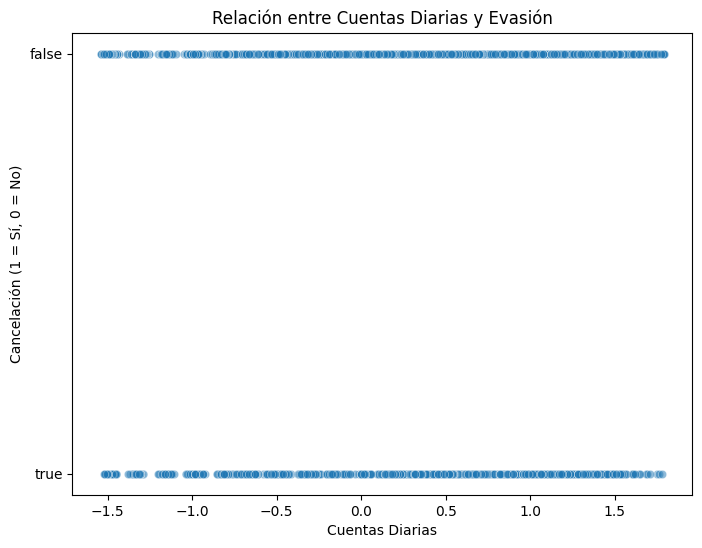

In [55]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_clean, x='Cuentas_Diarias', y=col_objetivo, alpha=0.5)
plt.title("Relación entre Cuentas Diarias y Evasión")
plt.xlabel("Cuentas Diarias")
plt.ylabel("Cancelación (1 = Sí, 0 = No)")
plt.show()

Interpretación

• 	Si ves correlaciones positivas con , significa que valores altos de esa variable se asocian con mayor probabilidad de cancelación (ej. cargos mensuales altos).
• 	Si la correlación es negativa, valores altos de esa variable se asocian con menor probabilidad de cancelación (ej. mayor tiempo de contrato).
• 	El scatterplot te permite ver si hay una tendencia clara o si la relación es más dispersa.


In [121]:
df_clean.to_csv('datos_tratados.csv', index=False)

##Informe Final: Análisis de Evasión de Clientes (Churn

#####Introducción

El objetivo de este análisis es comprender el comportamiento de los clientes en relación con la evasión (Churn), es decir, la cancelación del servicio. La evasión de clientes es un problema crítico para las empresas de telecomunicaciones, ya que impacta directamente en los ingresos y en la sostenibilidad del negocio. Identificar patrones y factores asociados al churn permite diseñar estrategias de retención más efectivas.


#### Limpieza y Tratamiento de Datos
- Se importaron los datos originales y se revisó la estructura del DataFrame.
- Se realizaron pasos de limpieza:
- Conversión de columnas numéricas (cargo mensual, cargo total, tenure) desde texto a valores numéricos.
- Creación de la variable Cuentas_Diarias dividiendo los cargos mensuales por 30.
- Normalización de categorías y traducción de nombres de columnas para mayor claridad.
- Se aplicó One-Hot Encoding a la variable objetivo Churn, generando cancelacion_Yes y cancelacion_No. Se seleccionó cancelacion_Yes como variable principal para el análisis.


####2. Análisis Exploratorio de Datos
- Distribución de la variable objetivo:
- Se observó la proporción de clientes que cancelaron vs. los que permanecieron mediante gráficos de barras y circulares.
- Variables categóricas:
- Se exploró la evasión según categorías como tipo de contrato, método de pago y servicio de internet (cuando disponibles).
- Se identificaron diferencias en la tasa de cancelación entre perfiles de clientes.
- Variables numéricas:
- Se analizaron MonthlyCharges, TotalCharges, tenure y Cuentas_Diarias mediante boxplots e histogramas comparativos.
- Se observó que clientes con tenure bajo (poco tiempo de contrato) y cargos mensuales altos tienden a cancelar con mayor frecuencia.


####3. Conclusiones e Insights
- La evasión está más concentrada en clientes nuevos (bajo tenure), lo que sugiere problemas de fidelización temprana.
- Los clientes con cargos mensuales más altos muestran mayor propensión a cancelar, indicando sensibilidad al precio.
- El análisis de Cuentas_Diarias refuerza que un gasto elevado diario se asocia con mayor churn.
- La variable objetivo cancelacion_Yes es la más adecuada para modelar y entender el comportamiento de los clientes.




####4. Recomendaciones
- Programas de fidelización temprana: ofrecer beneficios a clientes en sus primeros meses para reducir la tasa de cancelación inicial.
- Segmentación por nivel de gasto: diseñar planes más flexibles o descuentos para clientes con cargos mensuales altos.
- Monitoreo continuo: implementar dashboards que sigan la evolución de churn en tiempo real.
- Campañas personalizadas: usar insights de variables categóricas (contrato, método de pago, servicio de internet) para dirigir acciones específicas a los segmentos más vulnerables.
- Modelos predictivos: entrenar un modelo de machine learning con cancelacion_Yes como variable objetivo para anticipar qué clientes tienen mayor probabilidad de cancelar.


